In [1]:
import os
import sys
import anndata as ad
import numpy as np

import pandas as pd
import seaborn as sb
import metacells as mc

nb_dir = os.path.dirname(os.path.abspath("__file__"))  
project_root = os.path.abspath(os.path.join(nb_dir, "..", ".."))
sys.path.append(os.path.join(project_root, "utils"))

import constants
import utils
import principle_curve

import tqdm 
import time

from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon
from scipy.stats import chi2


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm


import multiprocessing as mp
from functools import partial
import tqdm



2025-12-30 13:54:36.505655: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-30 13:54:36.546240: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/rpy2/robjects/packages_utils.py:127: UserWarning: Conflict when converting R symbols in the package "princurve" to Python symbols: 
-lines_principal_curve -> lines.principal_curve, lines.principal.curve
- plot_principal_curve -> plot.principal_curve, plot.principal.curve
- poi

In [ ]:
cells_ad = ad.read_h5ad(constants.CELLS_PATH)

metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

gene_modules_dict = utils.load_pickle(constants.GENE_MODULES_DICT_PATH)

## Add gene modules information 

In [8]:
# Add gene modules scores to metacells
metacells_ad = utils.add_gene_modules_score(metacells_ad, modules_to_score_dict=gene_modules_dict)  # Geomean of gene module expression
metacells_ad = utils.add_gene_modules_summed_score(metacells_ad, modules_to_score_dict=gene_modules_dict, epsilon = 0, log_base=1, suffix="sum") # Sum of the gene modules expression

/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/metacells/utilities/annotation.py:1027: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[name] = data
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/metacells/utilities/annotation.py:1027: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[name] = data
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/metacells/utilities/annotation.py:1027: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

In [ ]:
# Add gene modules scores to cells

target_umis = 2**10 

cells_ad = utils.downsample_cells(cells_ad, target_umis=target_umis) 
cells_ad = utils.add_gene_modules_score(cells_ad, modules_to_score_dict=gene_modules_dict)
cells_ad = utils.add_gene_modules_summed_score(cells_ad, modules_to_score_dict=gene_modules_dict, layer="downsampled", epsilon = 0, log_base=1, suffix="sum")

for i in cells_ad.obs.columns:
    if "downsampled_score" in i:
        mc.ut.set_o_data(cells_ad, i.replace("_downsampled",""), cells_ad.obs[i].values)

Downsampling to 1024 UMIs


set unnamed.layers[downsampled]: csr_matrix 67332 X 36497 float32s (45337243 > 0, 1.845%)
set unnamed.uns[downsample_samples]: 1024
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/metacells/utilities/annotation.py:1027: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[name] = data
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/metacells/utilities/annotation.py:1027: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[name] = data
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.

## Calculate pseudotime for metacells 

In [ ]:
trajectories_sort_ascending = {
    "Ery":False,
    "Basophils":False,
    "Mast":True,
    "Eosinophil":True,
    "MK":False,
    "Neutrophils":False,
    "Monocyte":True,
}


trajectories_pseudotime_n_components = {
    "Ery":3,
    "Basophils":2,
    "Mast":2,
    "Eosinophil":2,
    "MK":2,
    "Neutrophils":3,
    "Monocyte":3,
}


cell_type_rename = {
    'baso': 'Basophils',
    'mast' : 'Mast',
    'eosinophil' : 'Eosinophil',
    'mk' : 'MK',
    'ery' : 'Ery',
    'monocyte' : 'Monocyte',
    'neut' : 'Neutrophils',
}

gene_modules_scores_per_type = {
    "Basophils": [],
    "Mast": [],
    "Eosinophil": [],
    "MK": [],
    "Ery": [],
    "Monocyte": [],
    "Neutrophils": [],
}

for i in gene_modules_dict:
    cell_type = i.split("_")[0]
    cell_type = cell_type_rename[cell_type]
    gene_modules_scores_per_type[cell_type].append(i + "_score_sum")

/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/rpy2/robjects/packages_utils.py:127: UserWarning: Conflict when converting R symbols in the package "princurve" to Python symbols: 
-lines_principal_curve -> lines.principal_curve, lines.principal.curve
- plot_principal_curve -> plot.principal_curve, plot.principal.curve
- points_principal_curve -> points.principal_curve, points.principal.curve
  warn(msg)


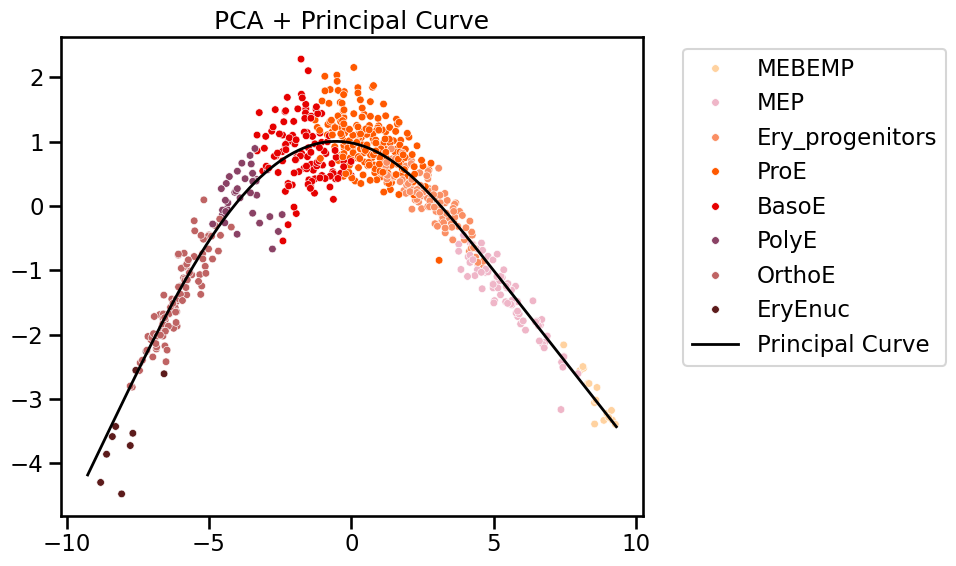

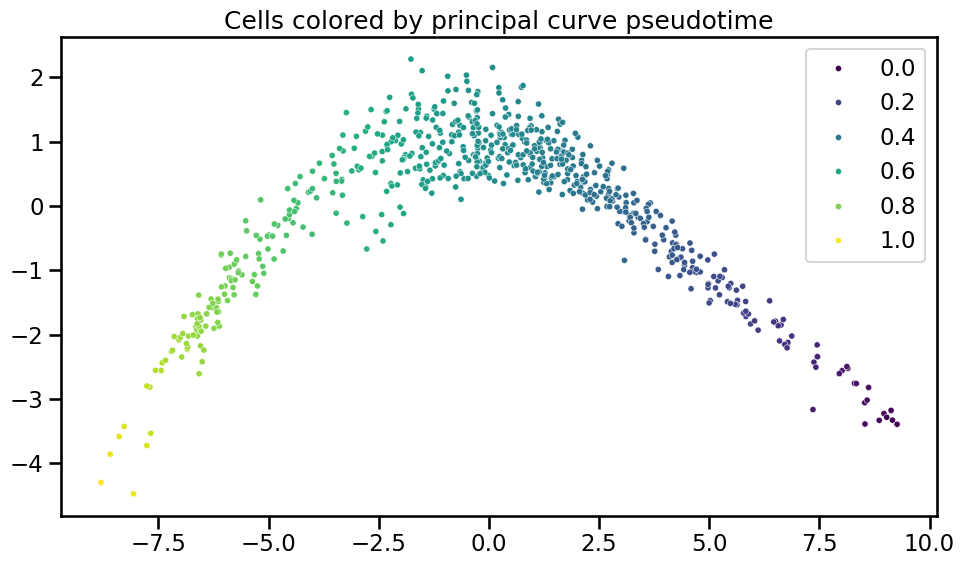

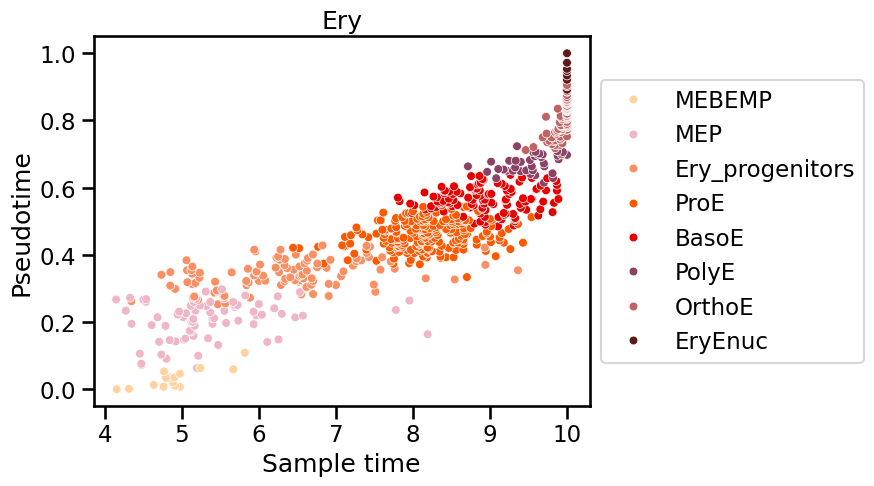

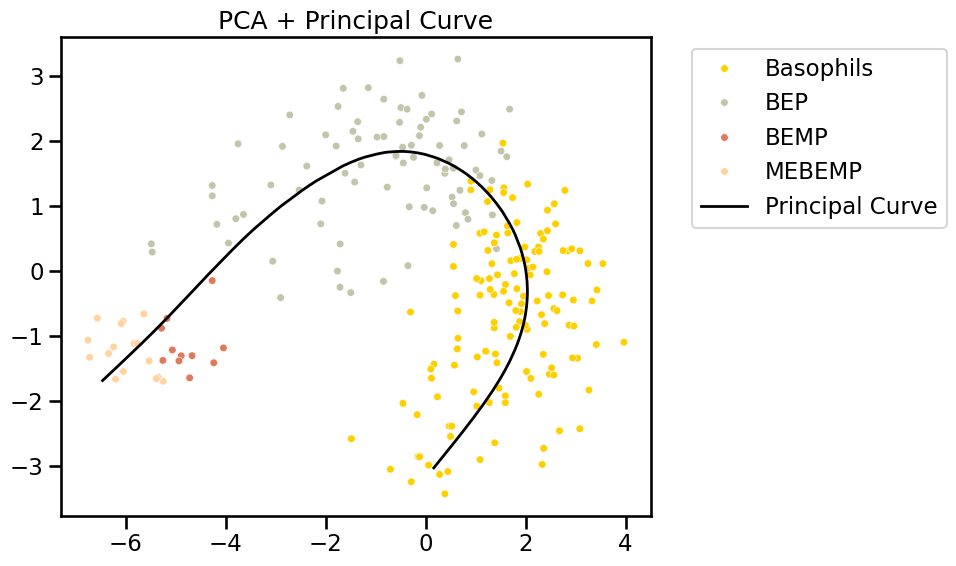

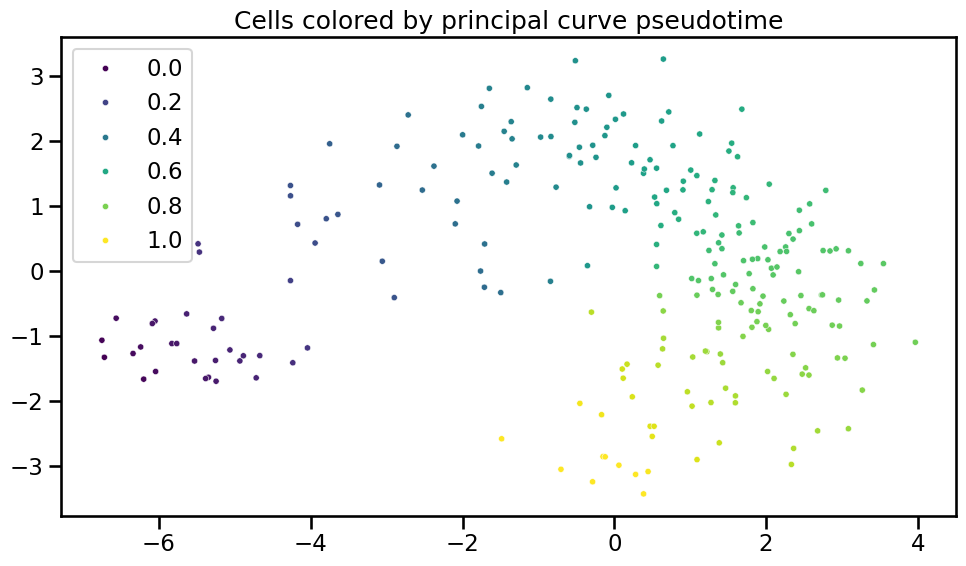

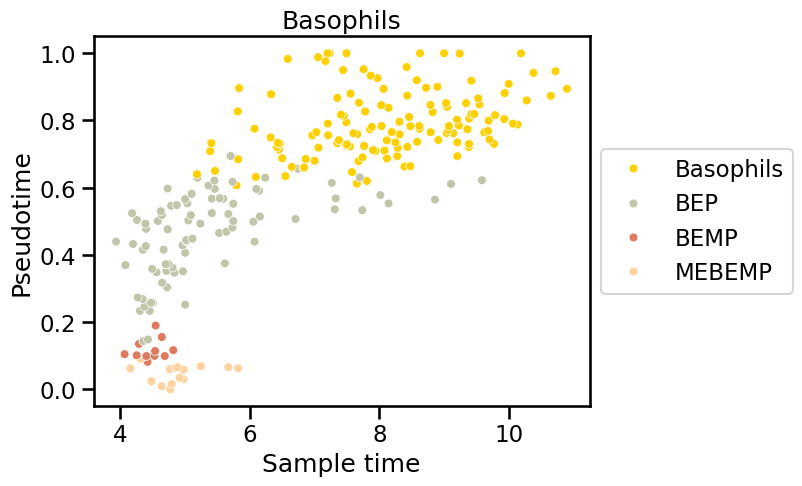

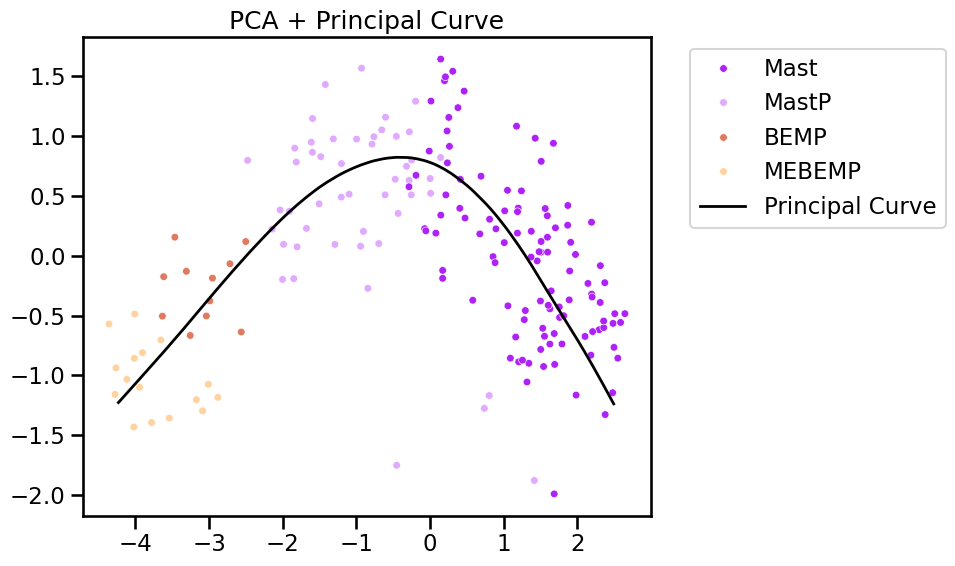

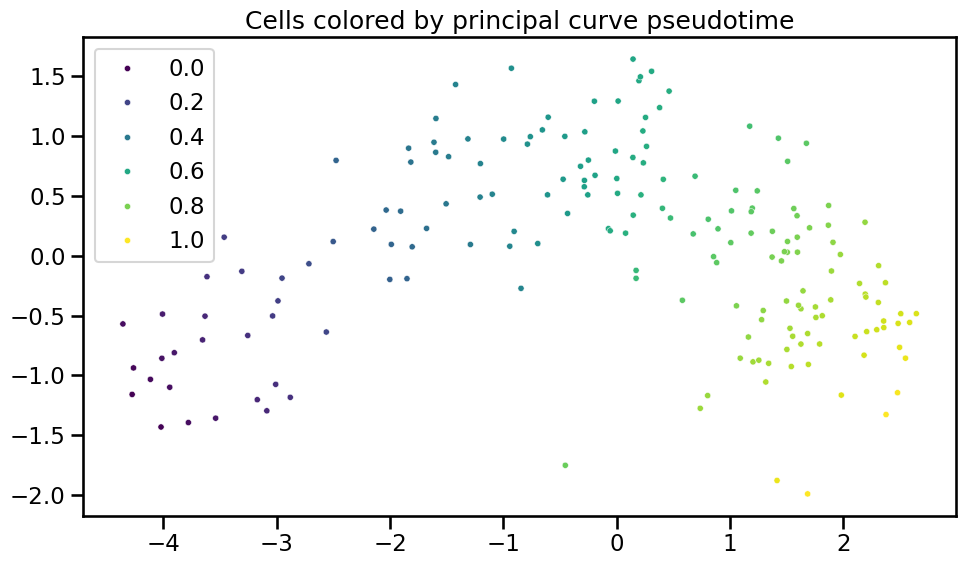

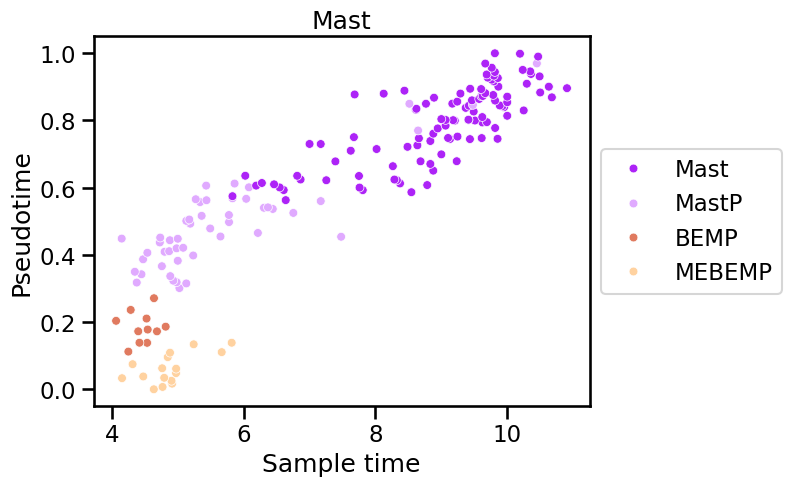

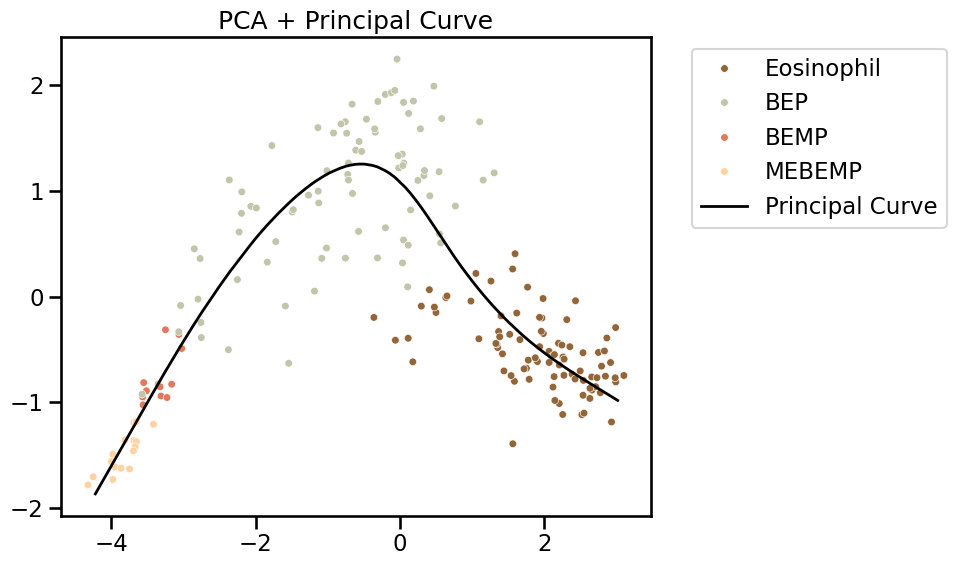

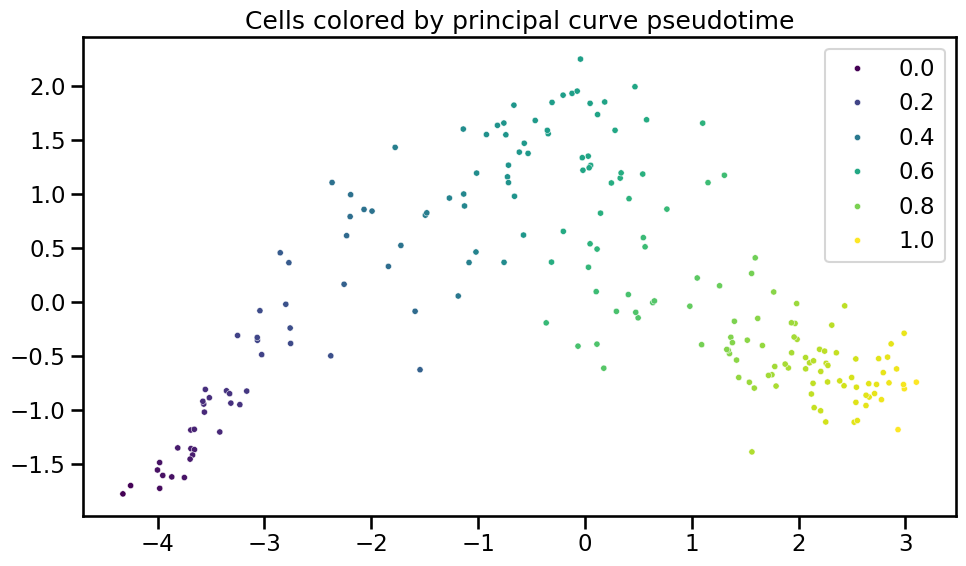

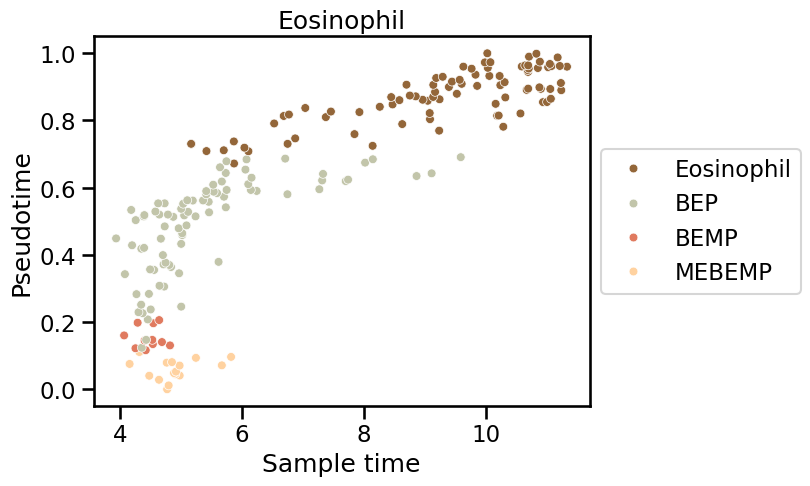

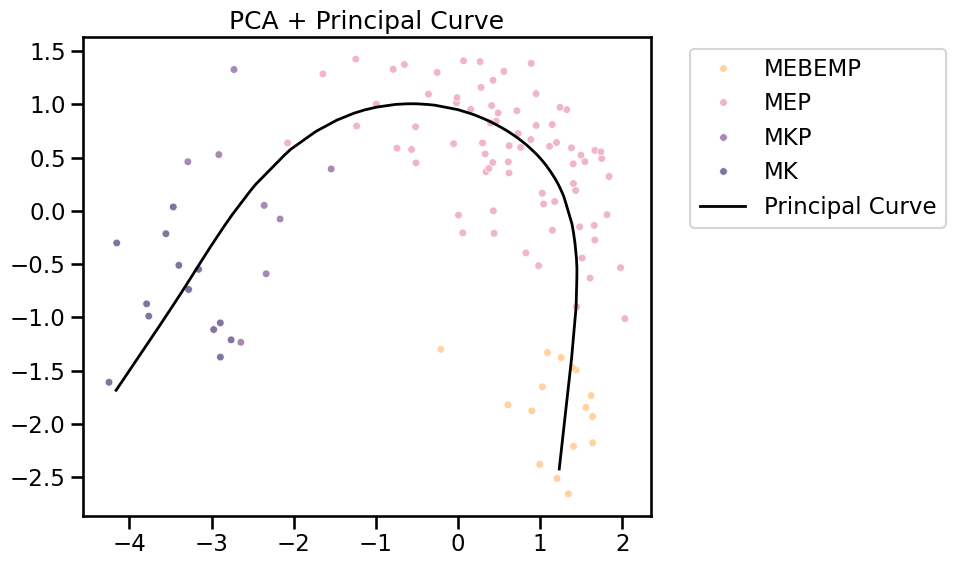

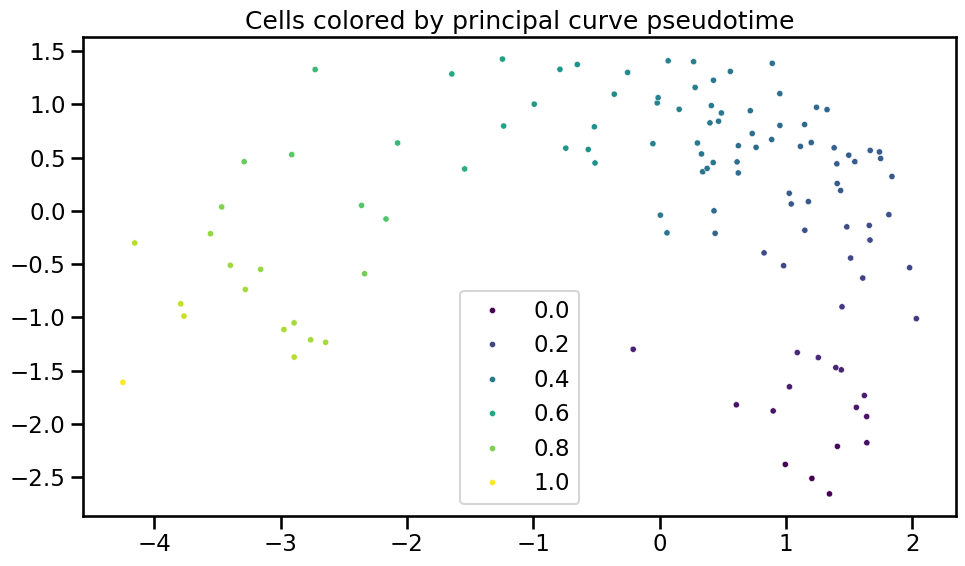

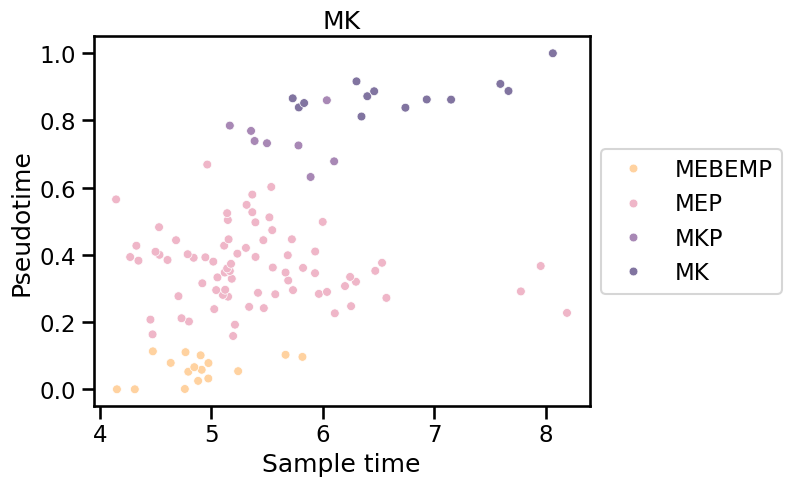

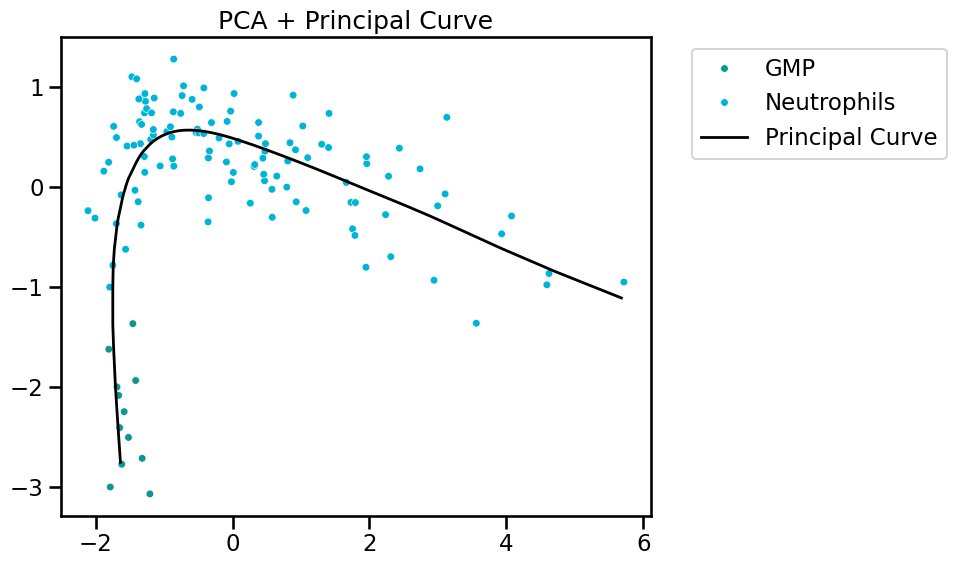

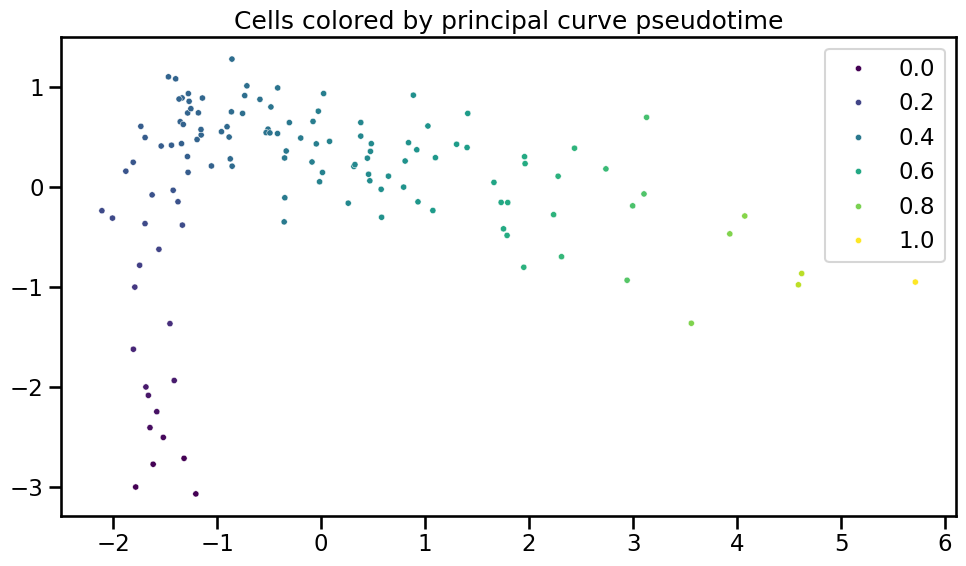

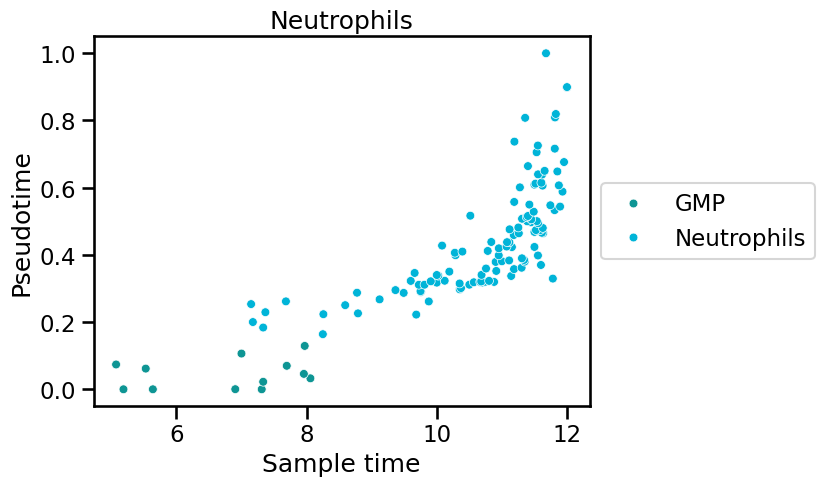

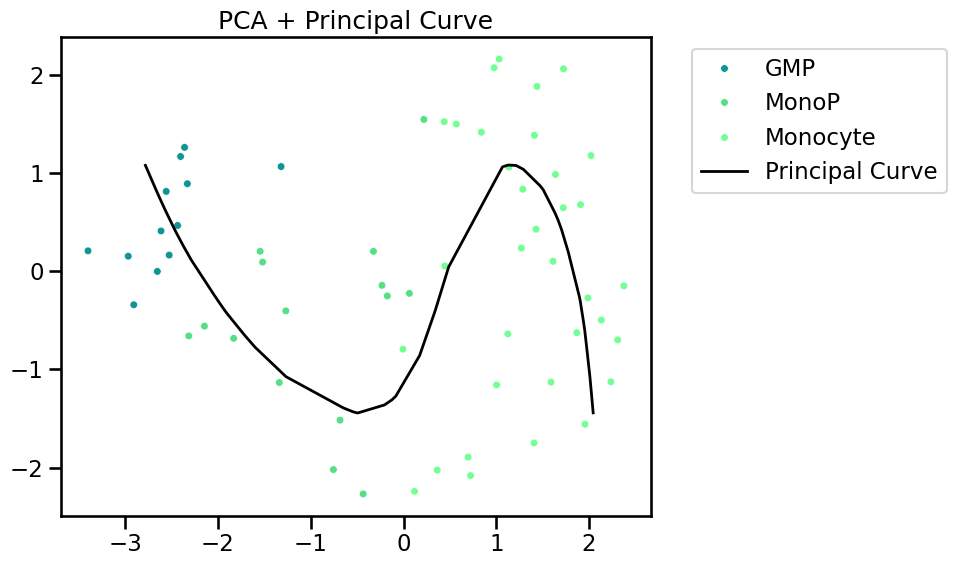

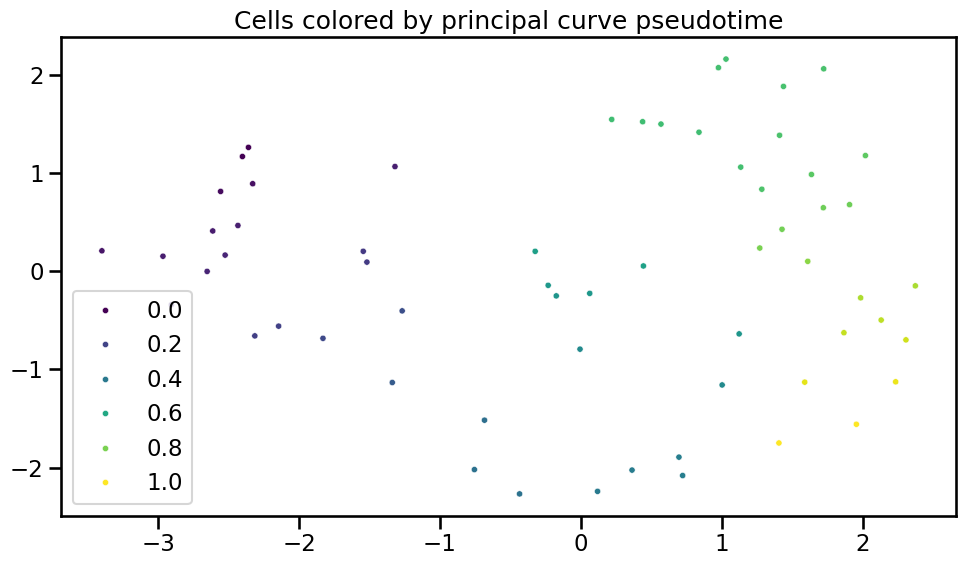

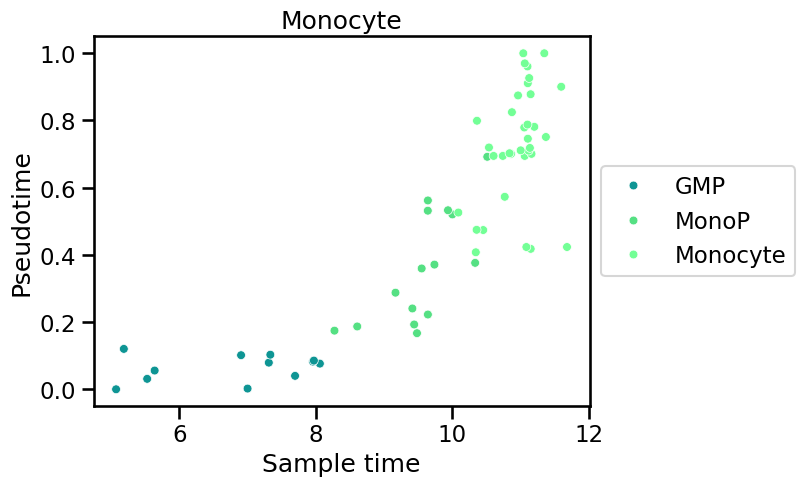

In [19]:
trajectory_pc_mapper = {}

for trajectory in constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT:
    trajectory_psedutime_series = pd.Series(None, index=metacells_ad.obs.index)
    trajectory_genes_modules = [i for i in gene_modules_scores_per_type[trajectory]]
    
    trajectory_top_level_cell_type = constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]

    trajectory_metacells = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.top_level_cell_type.isin(trajectory_top_level_cell_type))
        
    clusters_expression = trajectory_metacells.obs[[i for i in trajectory_genes_modules if i not in []]]

    pc = principle_curve.PrincipleCurve(n_components=trajectories_pseudotime_n_components[trajectory], reverse_order=trajectories_sort_ascending[trajectory])
    mc_pseudo_time_series = pc.fit(clusters_expression, show_plots=True, hue=trajectory_metacells.obs.loc[clusters_expression.index].type, palette=cell_type_colors)
    
    mc_abs_time_series = trajectory_metacells[mc_pseudo_time_series.index].obs.avg_day

    trajectory_psedutime_series[mc_pseudo_time_series.index] = mc_pseudo_time_series
    mc.ut.set_o_data(metacells_ad, "%s_pseudotime" % trajectory, trajectory_psedutime_series)

    sb.scatterplot(x=mc_abs_time_series, y=mc_pseudo_time_series, hue=trajectory_metacells[mc_abs_time_series.index].obs.type, palette=cell_type_colors, s=40)
    plt.title(trajectory)
    plt.xlabel("Sample time")
    plt.ylabel("Pseudotime")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    
    trajectory_pc_mapper[trajectory] = pc

In [20]:
# Add pseudotime to cells

In [ ]:
for trajectory in trajectory_pc_mapper:

    pc = trajectory_pc_mapper[trajectory]
    trajectory_genes_modules = [i for i in gene_modules_scores_per_type[trajectory]]

    trajectory_top_level_cell_type = constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]
    trajectory_cells_ad = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(trajectory_top_level_cell_type))
    
    # maybe each cell type need different downsample

    # re-calculate pseudotime for trajectory cells
    cells_expression = trajectory_cells_ad.obs[trajectory_genes_modules]
        
    # Project new cells
    trajectory_psedutime_series = pc.predict(cells_expression, show_plots=False)
    trajectory_psedutime_series = np.clip(trajectory_psedutime_series, 0,1)

    cells_pseudotime = pd.Series(None, index=cells_ad.obs.index)
    cells_pseudotime.loc[trajectory_psedutime_series.index] = trajectory_psedutime_series.values

    mc.ut.set_o_data(cells_ad, "%s_pseudotime" % trajectory, cells_pseudotime.values)

In [22]:
# for trajectory in trajectory_pc_mapper:
#     plt.figure(figsize=(4,6))
#     sb.boxplot(x="cell_type", y="%s_pseudotime" % trajectory, data=cells_ad[cells_ad.obs["%s_pseudotime" % trajectory].notna(), :].obs, palette=cell_type_colors,
#             order=[i for i in cell_type_colors if i in cells_ad[cells_ad.obs["%s_pseudotime" % trajectory].notna(), :].obs.cell_type.unique()])
#     plt.xticks(rotation=90)
#     plt.show()

In [ ]:
# Update all datasets
cells_ad.write_h5ad(constants.CELLS_PATH)
metacells_ad.write_h5ad(constants.METACELLS_PATH)
utils.save_to_pickle(trajectory_pc_mapper, constants.TRAJECTORY_PC_MAPPER)